# 3D Demo
This notebook shows the most important and usefull features of the Subwavelength 3D code


In [1]:
# You need to run the code form the /subwavelength-physics directory
import os
import sys

# Create a .env file and save there your base subwavelength-physics dir as BASE_DIR
from dotenv import load_dotenv

load_dotenv("../.env")


# Path to folder cloned from GitHub
sys.path.append(
    os.getenv('BASE_DIR')
)

In [2]:
os.getenv('BASE_DIR')

'/home/silvio/Documents/01_academic/subwavelength-physics'

In [12]:
import matplotlib.pyplot as plt
import time

In [3]:
from Subwavelength3D.classic_finite import ClassicFiniteSWP3D

In [5]:
# Get a chain of resonators

fwp=ClassicFiniteSWP3D.get_chain(N=10, sep=2,radius=1)
fwp

Three Dimensional Finite system with 10 resonators.
Geometry:     The first centers are
[[ 0  0  0]
 [ 0  0  4]
 [ 0  0  8]
 [ 0  0 12]
 [ 0  0 16]] and the first radii are [1. 1. 1. 1. 1.].
Physics:      Classic system

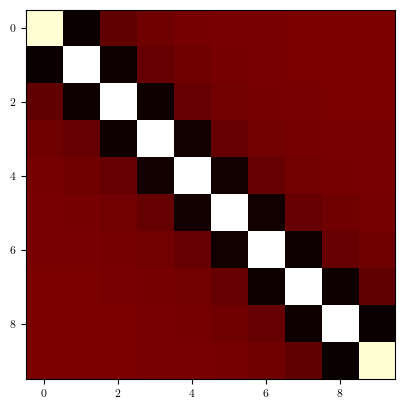

In [9]:
C = fwp.get_capacitance_matrix(N_multipole=2,method="general",k0=1e-5,N_jobs=8)
plt.imshow(C, cmap='hot', interpolation='nearest')
plt.show()

Computing large capacitance matrices is typically time consuming. Using the fmm method we can speed this up. Read the README file in the base dir to see how to get that running.

In [29]:
fwp=ClassicFiniteSWP3D.get_chain(N=30, sep=2,radius=1)
t0 = time.time()
C = fwp.get_capacitance_matrix(N_multipole=2,method="general",k0=1e-5,N_jobs=8)
print(f"General needs {time.time() - t0:.2f} seconds")

General needs 0.08 seconds


In [30]:
t0 = time.time()
C = fwp.get_capacitance_matrix(N_multipole=2,method="fmm",k0=1e-5,N_jobs=8)
print(f"FMM needs {time.time() - t0:.2f} seconds")

FMM needs 0.18 seconds


In [31]:
D,S = fwp.compute_sorted_eigs_capacitance_matrix()

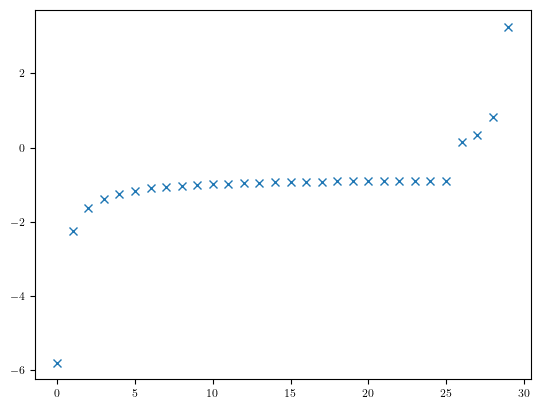

In [32]:
plt.plot(D,'x')

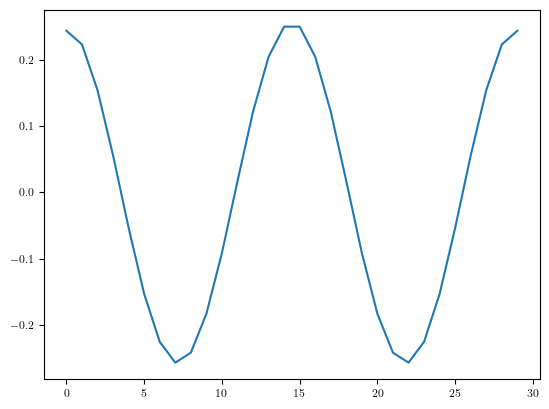

In [36]:
_ = plt.plot(S[:,0])